# Analisis predictivo del NASDAQ 

# 1.Instalo e importo los requerimientos y paquetes necesarios


In [1]:
pip install -r requirements.py



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf


### Descago los datos del nasdaq

In [3]:
datos_nasdaq = yf.download('^IXIC', start='2025-01-01')

[*********************100%***********************]  1 of 1 completed


### Compruebo los resultado

In [4]:
### Primeros resultados
print(datos_nasdaq.head())
### ultimos resultado 
print(datos_nasdaq.tail())

Price              Close          High           Low          Open  \
Ticker             ^IXIC         ^IXIC         ^IXIC         ^IXIC   
Date                                                                 
2025-01-02  19280.789062  19517.869141  19117.589844  19403.900391   
2025-01-03  19621.679688  19638.660156  19379.570312  19395.509766   
2025-01-06  19864.980469  20007.949219  19785.000000  19851.990234   
2025-01-07  19489.679688  19940.210938  19421.019531  19938.080078   
2025-01-08  19478.880859  19544.509766  19308.539062  19469.369141   

Price            Volume  
Ticker            ^IXIC  
Date                     
2025-01-02   8737550000  
2025-01-03   8214050000  
2025-01-06   9586840000  
2025-01-07  13371130000  
2025-01-08   8851720000  
Price              Close          High           Low          Open      Volume
Ticker             ^IXIC         ^IXIC         ^IXIC         ^IXIC       ^IXIC
Date                                                                     

### Dimensiones de dataframe
    nos dice fila y columnas

In [5]:
print(datos_nasdaq.shape)

(419, 5)


In [6]:
datos_nasdaq.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 419 entries, 2025-01-02 to 2026-09-03
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^IXIC)   419 non-null    float64
 1   (High, ^IXIC)    419 non-null    float64
 2   (Low, ^IXIC)     419 non-null    float64
 3   (Open, ^IXIC)    419 non-null    float64
 4   (Volume, ^IXIC)  419 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 19.6 KB


### count → número de valores.
### mean → media.
### std → desviación estándar.
### min → mínimo.
### 25% → primer cuartil.
### 50% → mediana.
### 75% → tercer cuartil.
### max → máximo.

In [7]:
datos_nasdaq.describe()


Price,Close,High,Low,Open,Volume
Ticker,^IXIC,^IXIC,^IXIC,^IXIC,^IXIC
count,419.000000,419.000000,419.000000,419.000000,4.190000e+02
mean,22153.088865,22295.933496,21982.108944,22148.159054,8.931130e+09
std,2815.254714,2808.278745,2824.533480,2821.939958,1.713599e+09
min,15267.910156,16066.790039,14784.030273,14978.030273,2.114605e+09
25%,19724.290039,19901.375000,19577.490234,19777.114258,7.908230e+09
50%,22564.230469,22735.779297,22397.000000,22542.279297,8.627780e+09
75%,23729.430664,23855.695312,23618.205078,23750.790039,9.760515e+09
max,27093.900391,27190.210938,26932.769531,27092.849609,1.828615e+10


# Visualización de mis datos en grafica

In [8]:
import matplotlib.pyplot as plt

### Importante comprobar la estructura de mis datos para ver como trabajamos con ella

In [9]:
datos_nasdaq.index

DatetimeIndex(['2025-01-02', '2025-01-03', '2025-01-06', '2025-01-07',
               '2025-01-08', '2025-01-10', '2025-01-13', '2025-01-14',
               '2025-01-15', '2025-01-16',
               ...
               '2026-08-21', '2026-08-24', '2026-08-25', '2026-08-26',
               '2026-08-27', '2026-08-28', '2026-08-31', '2026-09-01',
               '2026-09-02', '2026-09-03'],
              dtype='datetime64[s]', name='Date', length=419, freq=None)

In [10]:
datos_nasdaq.columns

MultiIndex([( 'Close', '^IXIC'),
            (  'High', '^IXIC'),
            (   'Low', '^IXIC'),
            (  'Open', '^IXIC'),
            ('Volume', '^IXIC')],
           names=['Price', 'Ticker'])

Text(0, 0.5, 'Precio de cierre')

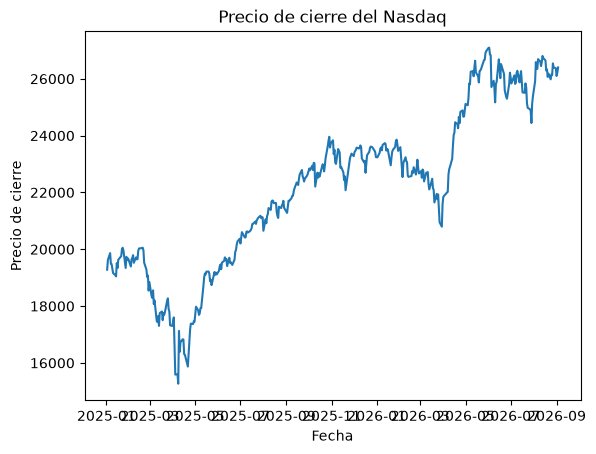

In [11]:
fig, ax = plt.subplots()
ax.plot(datos_nasdaq.index, datos_nasdaq['Close'])
ax.set_title('Precio de cierre del Nasdaq')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio de cierre')


### Listo pero ahora las fechas colapsan por que hay demasiados datos, vamos a solucionar esto

In [12]:
import matplotlib.dates as mdates

### Conceptos:
# fig
 ## └── ax
          ├── línea
          ├── título
          ├── ejes
          ├── etiquetas
          └── ticks

### fig es el contenedor completo.
### ax es la zona donde ocurre el gráfico.
### Y plt es la interfaz que proporciona Matplotlib para controlar muchas cosas de forma global.

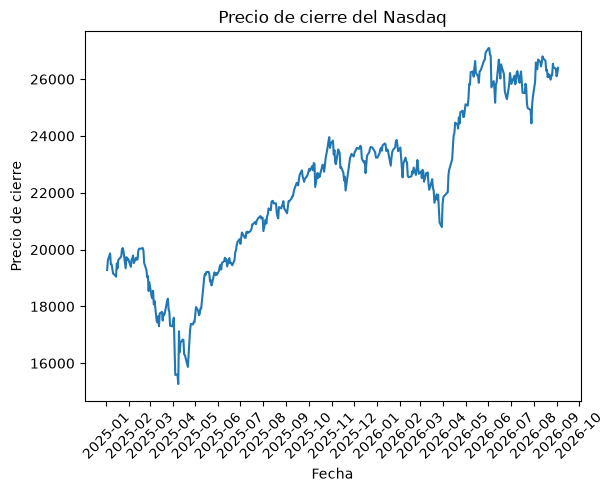

In [13]:

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45)
fig

In [14]:
datos_nasdaq['Close'].describe()

Ticker,^IXIC
count,419.000000
mean,22153.088865
std,2815.254714
min,15267.910156
25%,19724.290039
50%,22564.230469
75%,23729.430664
max,27093.900391


### Precio de cierre maximo

In [15]:
cierre_nasdaq = datos_nasdaq['Close']
precio_maximo = cierre_nasdaq.max()
fecha_cierre_maximo = cierre_nasdaq.idxmax()
print(f'El precio máximo de cierre del Nasdaq es: {precio_maximo} para el dia {fecha_cierre_maximo}')

El precio máximo de cierre del Nasdaq es: Ticker
^IXIC    27093.900391
dtype: float64 para el dia Ticker
^IXIC   2026-06-02
dtype: datetime64[s]


   ### Calculo del cambio de manera automatica

In [16]:
retorno =datos_nasdaq["Close"].pct_change()
retorno_porcentual = retorno * 100
print(retorno)

Ticker         ^IXIC
Date                
2025-01-02       NaN
2025-01-03  0.017680
2025-01-06  0.012400
2025-01-07 -0.018893
2025-01-08 -0.000554
...              ...
2026-08-28 -0.005234
2026-08-31 -0.001194
2026-09-01 -0.010281
2026-09-02  0.004523
2026-09-03  0.006966

[419 rows x 1 columns]


### Esto es forma manual

In [17]:
precio_1 =datos_nasdaq['Close'].iloc[0]
precio_2 =datos_nasdaq['Close'].iloc[1]
retorno_esperado = (precio_2 - precio_1) / precio_1
print(retorno_esperado)

Ticker
^IXIC    0.01768
dtype: float64


## Histograma de tasa de cambio


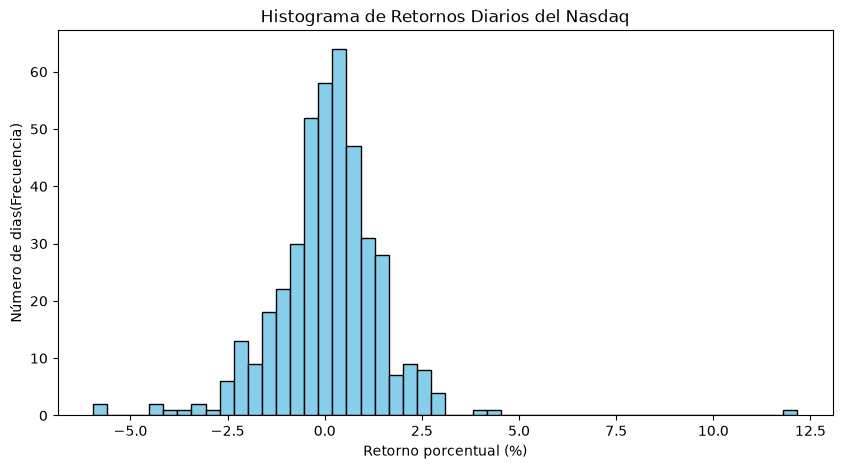

In [18]:
#Limpiar retorno del NaN
retorno_limpio = retorno.dropna() * 100
plt.figure(figsize=(10, 5))
plt.hist(retorno_limpio, bins=50, color='skyblue', edgecolor='black')

# Titulos y etiquetas para el grafico
plt.title('Histograma de Retornos Diarios del Nasdaq')
plt.xlabel('Retorno porcentual (%)')
plt.ylabel('Número de dias(Frecuencia)')
plt.show()

## Análisis de la Distribución de Retornos Diarios del Nasdaq

Lo que observamos en este histograma es la tasa de cambio de los precios de cierre. Básicamente, la figura adopta la forma de una **campana de Gauss**, donde los rangos se mueven muy cerca del 0% (principalmente entre -1% y 1%), concentrando allí el mayor porcentaje de las variaciones diarias del Nasdaq.

De este comportamiento podemos destacar los siguientes puntos clave:

* **Probabilidad y Dispersión:** Cuanto más nos alejamos —de forma positiva o negativa— del centro de la campana, menor es la probabilidad de que se produzca un cambio de esa magnitud en el precio.
* **Valores Atípicos (*Outliers*):** Encontramos tasas de cambio cercanas al 5% (tanto al alza como a la baja) de manera muy aislada. Se trata de **casos extraordinarios**, jornadas donde la volatilidad se disparó de forma inusual debido a noticias macroeconómicas o eventos puntuales de alto impacto.